In [103]:
# Parameters
param1=1

In [104]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy

from torch import nn
from umap import UMAP

from run_sim import *
from utils import cosine_similarity, get_r_2, vector_angle
from tqdm import tqdm
from tqdm import tqdm
from utils import *
import matplotlib as mpl
from functools import reduce



In [105]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [106]:
C = Config()

C.G = 0.5
C.linear_net = False
C.corridor_dim = 2
C.learning_rate = 0.01
C.L=5
C.print_progress = True
C.length_corridors = [5]*1
C.max_move = 1
C.hidden_size = 100
C.num_epochs *= 1
C.algo_name = 'SGD'
C.loss_fn = nn.CrossEntropyLoss()
# C.mask_states = [(1,1,),(2,1,),(3,1,)]

In [107]:

data_dict = run_sim_wrapper(C)

X = data_dict['X']
y = data_dict['y']
corridor = data_dict['corridor']
loc_X = data_dict['loc_X']
loc_y = data_dict['loc_y']
action_taken = data_dict['action_taken']
hidden_states = data_dict['hidden_states']
loss_l = data_dict['loss_l']
accuracy_l = data_dict['accuracy_l']
outputs = data_dict['outputs']
hidden_l = data_dict['hidden_l']
initial_weights = data_dict['initial_weights']
final_weights = data_dict['final_weights']
state_dict_l = data_dict['state_dict_l']
C = data_dict['C']

print(calc_h_var(C.G, X.shape[1], C.hidden_size, C.L, X.var().cpu().numpy()))
hidden = hidden_states[-1].detach().cpu().numpy()
X_dist = torch.cdist(X, X).cpu().numpy()
y_dist = torch.cdist(y, y).cpu().numpy()
hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
stay_inds = np.where(action_taken == 0)[0]
# loc_y_corridor = loc_y + (corridor * max(loc_y + 1))
n_corridors = len(C.length_corridors)

X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor
h_np = hidden  # Convert to numpy array if hidden is a torch tensor

Number of samples: 105
Input dimension: 31
Output dimension: 25
Number of actions: 6

Sig_2 of last hidden: 7.922191684883728e-07


100%|██████████| 10000/10000 [00:33<00:00, 300.53it/s]

2.790348729179134e-05


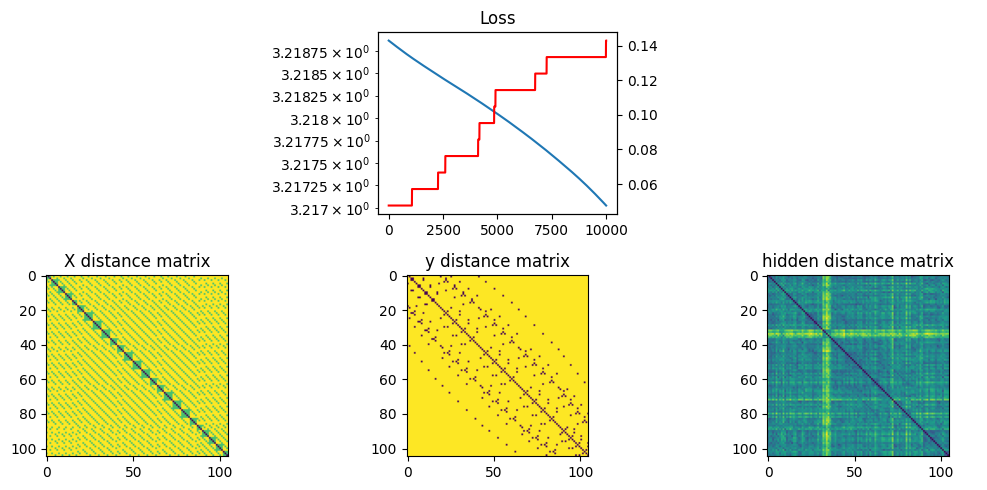

In [108]:
# indices = np.lexsort((loc_y, corridor))
# indices = indices[action_taken[indices]==0]
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
axs[0,1].plot(loss_l)
axs[0,1].set_yscale('log')
axs[0,1].twinx().plot(accuracy_l, 'r')
axs[0,1].set_title("Loss")
for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
    # ax.imshow(var[indices][:, indices], cmap='viridis')
    ax.imshow(var, cmap='viridis')
    ax.set_title(f'{var_name} distance matrix')
    ax.grid(False)
plt.tight_layout()
plt.show()

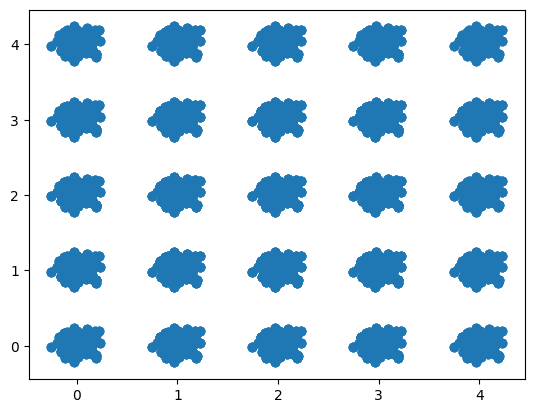

In [109]:
plt.scatter(loc_y[:,0]+np.random.randn(len(loc_y),1)*0.1, loc_y[:,1]+np.random.randn(len(loc_y),1)*0.1)

0.09632608294487


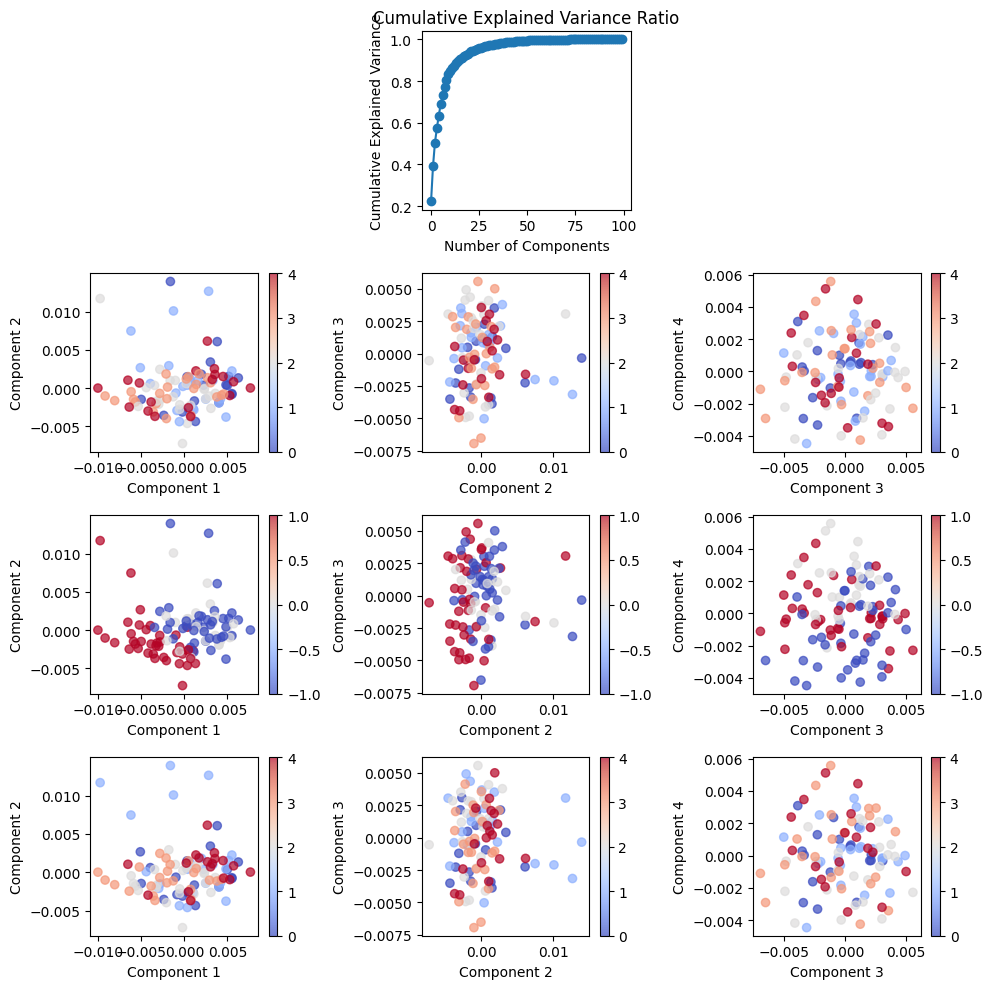

In [110]:
pca = PCA().fit(h_np)
X_reduced = pca.transform(h_np)
fig = plt.figure(figsize=(10, 10))

print(get_order(data_dict))

markers = ['o', '*', '^']
# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title(f'Cumulative Explained Variance Ratio')
cmaps = ['coolwarm', 'vanimo']
# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y[:,0], action_taken, loc_X[:,0]]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        for n in range(n_corridors):
            s = ax.scatter(X_reduced[corridor==n, i], X_reduced[corridor==n, i+1], c=c[corridor==n], cmap=cmaps[0], alpha=0.7, marker=markers[n])
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}'),
        # ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()

In [111]:

output_weights = final_weights['output_layer.weight'].cpu().detach().numpy()
n_corridors = len(C.length_corridors)
pca = PCA(); pca_corridors = [PCA() for _ in range(n_corridors)];
[p.fit(hidden[corridor == i]) for i, p in enumerate(pca_corridors)]
pca.fit(hidden)
h_transformed = pca.transform(h_np)
h_transformed_l = [p.transform(h_np[corridor == i]) for i, p in enumerate(pca_corridors)]
pca_accuracy_l = []
pca_explained_var_l = []
pca_loss_l = []
order_l = []
n_pcs = np.arange(1, min(min([min(h_transformed_l[i].shape) for i in range(n_corridors)]), 100))
for n in n_pcs:
    # h_reconstructed = pca.inverse_transform(h_transformed)
    h_reconstructed = h_transformed[:,:n] @ pca.components_[:n] + pca.mean_
    y_hat_pca = (h_reconstructed @ output_weights.T)
    # print(f'accuracy of first {n} PCs: {(y_hat_first_pc == y.argmax(1).cpu().detach().numpy()).mean()}')
    pca_accuracy_l.append((y_hat_pca.argmax(1) == y_np.argmax(1)).mean())
    pca_explained_var_l.append(pca.explained_variance_ratio_[:n].sum())
    pca_loss_l.append(nn.CrossEntropyLoss()(torch.tensor(y_hat_pca), y.cpu()).item())
    order = [get_r_2(h[:, [n-1]], loc_y[corridor == i]) for i, h in enumerate(h_transformed_l)]
    order_l.append(np.mean(order))

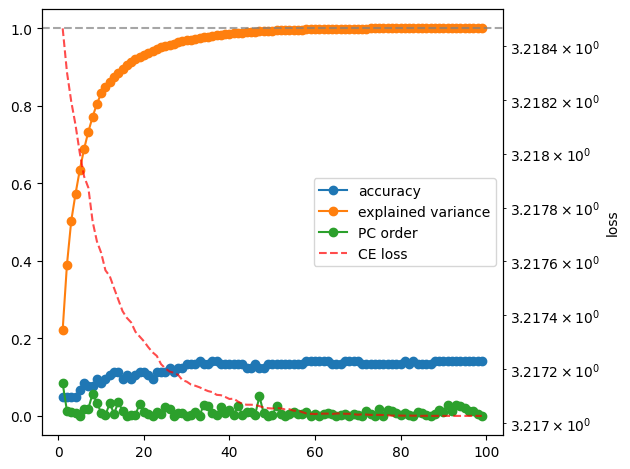

In [112]:
fig, ax1 = plt.subplots()
plt.plot(n_pcs, pca_accuracy_l, label='accuracy', marker='o')
plt.plot(n_pcs, pca_explained_var_l, label='explained variance', marker='o')
plt.plot(n_pcs, order_l, label='PC order', marker='o')
plt.axhline(1, color='gray', ls='--', alpha=0.7)
ax2 = ax1.twinx()
ax2.set_ylabel('loss')
ax2.plot(n_pcs, pca_loss_l, 'r', label='CE loss', ls='--', alpha=0.7)
ax2.set_yscale('log')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')
plt.xlabel('number of PCs')
# plt.xscale('log')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '$V_{11}$')

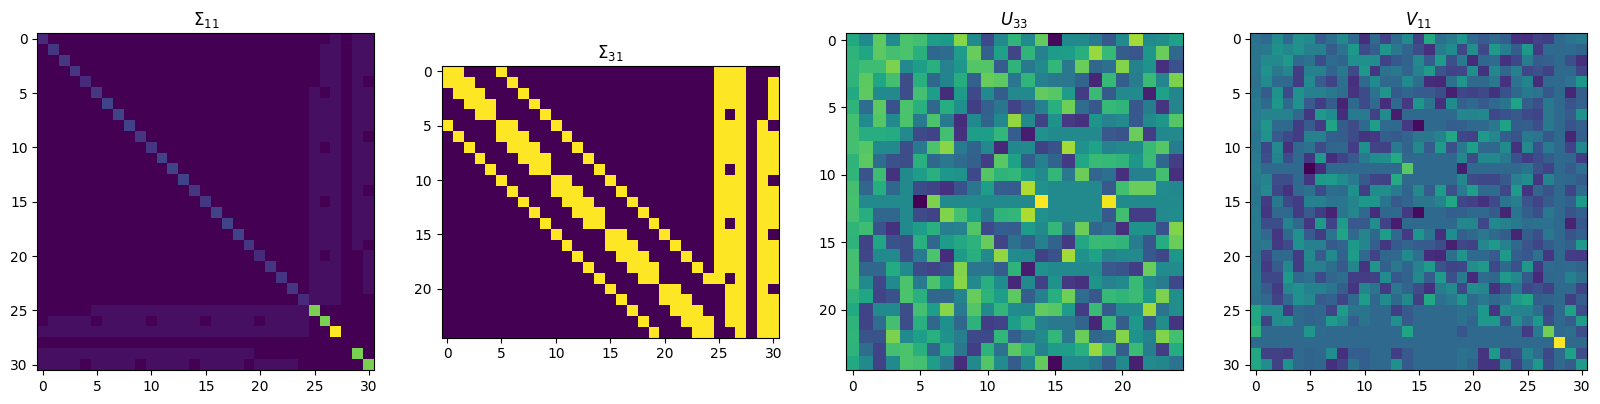

In [113]:

sigma11 = np.sum([xi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
U33,S, V11 = np.linalg.svd(sigma31)
V11 = V11.T

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(sigma11); axs[0].set_title('$\Sigma_{11}$')
axs[1].imshow(sigma31); axs[1].set_title('$\Sigma_{31}$')
axs[2].imshow(U33); axs[2].set_title('$U_{33}$')
axs[3].imshow(V11); axs[3].set_title('$V_{11}$')

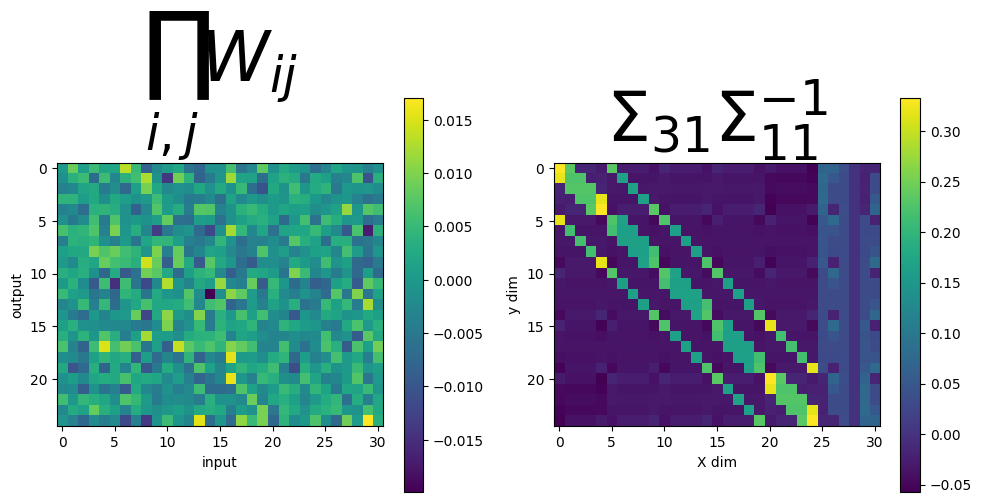

In [114]:
W_l = [W.cpu().numpy() for W in final_weights.values()]
result = W_l[0].T
for W in W_l[1:]:
    result = np.matmul(result, W.T)

# Sigma = np.corrcoef(X_np.T, y_np.T)
# Sigma31 = Sigma[X_np.shape[1]:, :X_np.shape[1]]
# Sigma11 = Sigma[:X_np.shape[1], :X_np.shape[1]]
Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X_np], 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
# ax1.imshow(W32@W21)
im = ax1.imshow(result.T, cmap='viridis')
plt.colorbar(im, ax=ax1)
ax1.set_ylabel('output')
ax1.set_xlabel('input')
ax1.set_title(r'$\prod_{i,j} W_{ij}$', fontsize=50)
im = ax2.imshow(Sigma31@np.linalg.pinv(Sigma11), cmap='viridis')
plt.colorbar(im, ax=ax2)
ax2.set_title('$\Sigma_{31}\Sigma_{11}^{-1}$', fontsize=50)
ax2.set_xlabel('X dim')
ax2.set_ylabel('y dim')
plt.tight_layout()
plt.show()

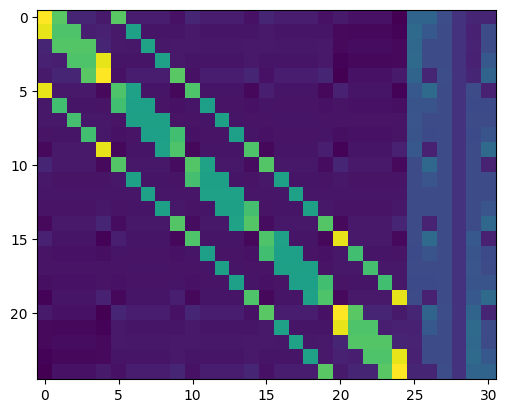

In [115]:
import numpy as np

def factorize_matrix(M, N=None):
    D1, D2 = M.shape
    # Compute full SVD
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    rank = np.sum(S > 1e-10)  # numerical rank

    if N is None:
        N = rank  # default N to rank(M)
    # elif N < rank:
    #     raise ValueError(f"N must be >= rank(M)={rank} for exact reconstruction")

    # Take the first N components
    U_N = U[:, :N]
    S_N = np.diag(S[:N])
    Vt_N = Vt[:N, :]

    A = U_N @ np.sqrt(S_N)
    B = np.sqrt(S_N) @ Vt_N
    return A, B

# Example:
M = Sigma31@np.linalg.pinv(Sigma11)
A, B = factorize_matrix(M, N=C.hidden_size)
M_reconstructed = A @ B
plt.imshow(M_reconstructed)


In [116]:
h_syntetic = X_np @ B.T
pca = PCA().fit(h_syntetic)
X_reduced = pca.transform(h_syntetic)

lamb_h = PCA().fit(hidden).explained_variance_
lamb_h_syn = PCA().fit(h_syntetic).explained_variance_
lamb_out = PCA().fit(outputs).explained_variance_
lamb_tag = PCA().fit(X_np @ sigma31.T).explained_variance_
lamb_X = PCA().fit(X_np).explained_variance_
lamb_y = PCA().fit(y_np).explained_variance_
print(f'PR model hidden = {lamb_h.sum() ** 2 / (lamb_h ** 2).sum()}')
print(f'PR synthetic hidden = {lamb_h_syn.sum() ** 2 / (lamb_h_syn ** 2).sum()}')
print(f'PR model output = {lamb_out.sum() ** 2 / (lamb_out ** 2).sum()}')
print(f'PR sigma31 output = {lamb_tag.sum() ** 2 / (lamb_tag ** 2).sum()}')
print(f'PR X = {lamb_X.sum() ** 2 / (lamb_X ** 2).sum()}')
print(f'PR y = {lamb_y.sum() ** 2 / (lamb_y ** 2).sum()}')


PR model hidden = 9.206541089225171
PR synthetic hidden = 16.854395723637566
PR model output = 4.59268516354073
PR sigma31 output = 9.024515763613215
PR X = 15.276968006135371
PR y = 23.385561901682994


In [117]:
from sklearn.svm import LinearSVC
# Train hard-margin SVM (C is large => hard margin)
clf = LinearSVC(fit_intercept=True, C=1e-9)
clf.fit(X_np, y_np.argmax(1))
w_SVM = clf.coef_
print(clf.score(X_np, y_np.argmax(1)))
print(((X_np@w_SVM.T + clf.intercept_[None,:]).argmax(1)==y_np.argmax(1)).mean())

0.2
0.2


In [118]:
from functools import reduce
W_effective = reduce(np.matmul, [W.cpu().numpy().T for W in final_weights.values()])
Corr_matrix = Sigma31@np.linalg.pinv(Sigma11)
clf = LogisticRegression(multi_class='multinomial', penalty=None)
clf.fit(X_np, y_np.argmax(1))
print(f'Model accuracy = {((X_np@W_effective).argmax(1)==y_np.argmax(1)).mean():.2f}')
print(f'Corr matrix accuracy = {((X_np@Corr_matrix.T).argmax(1)==y_np.argmax(1)).mean():.2f}')
print(f'Logistic regression accuracy = {accuracy_score(clf.predict(X_np), y_np.argmax(1)):.2f}')



Model accuracy = 0.08
Corr matrix accuracy = 0.77
Logistic regression accuracy = 1.00


c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


ValueError: The number of FixedLocator locations (31), usually from a call to set_ticks, does not match the number of labels (8).

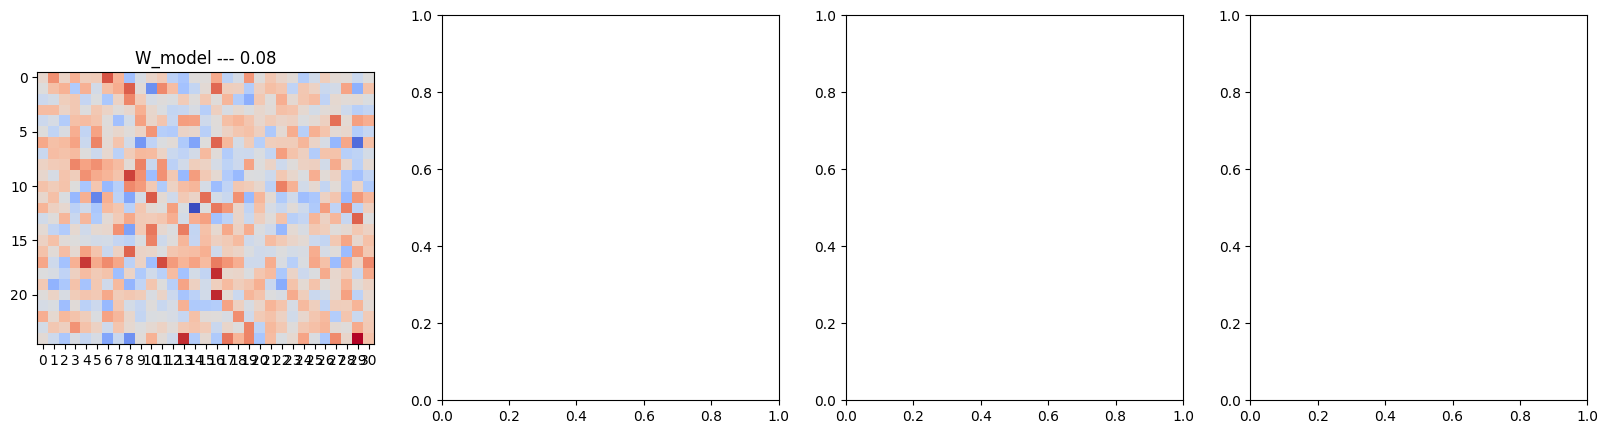

In [119]:
W_dict = {
    'W_model':reduce(np.matmul, [W.cpu().numpy().T for W in final_weights.values()]).T,
    'W_logistic':LogisticRegression(multi_class='multinomial', fit_intercept=False, tol=1e-8).fit(X_np, y_np.argmax(1)).coef_,
    'W_logistic_noreg':LogisticRegression(multi_class='multinomial', penalty=None, fit_intercept=False, tol=1e-8).fit(X_np, y_np.argmax(1)).coef_,
    'W_correlation':Sigma31@np.linalg.pinv(Sigma11),
}
# for k,v in W_dict.items():
#     W_dict[k] = v/v.max()
fig, axs = plt.subplots(1, 4, figsize=(20,5))
for ax, (W_name, W) in zip(axs, W_dict.items()):
    ax.imshow(W, cmap='coolwarm')
    ax.set_title(f'{W_name} --- {accuracy_score((X_np@W.T).argmax(1), y_np.argmax(1)):.2f}')
    ax.set_xticks(np.arange(X_np.shape[1]), [f's = {i}' for i in range(loc_y.max()+1)]+[f'a = {i}' for i in range(-C.max_move, C.max_move+1)], rotation=45)
    ax.grid(False)

In [ ]:
U, S, V = np.linalg.svd(W_dict['W_model'])
S[:3]

array([2.7014596, 1.3005168, 1.2394892], dtype=float32)

/home/avivra/PycharmProjects/RepresentationShaping/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/avivra/PycharmProjects/RepresentationShaping/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


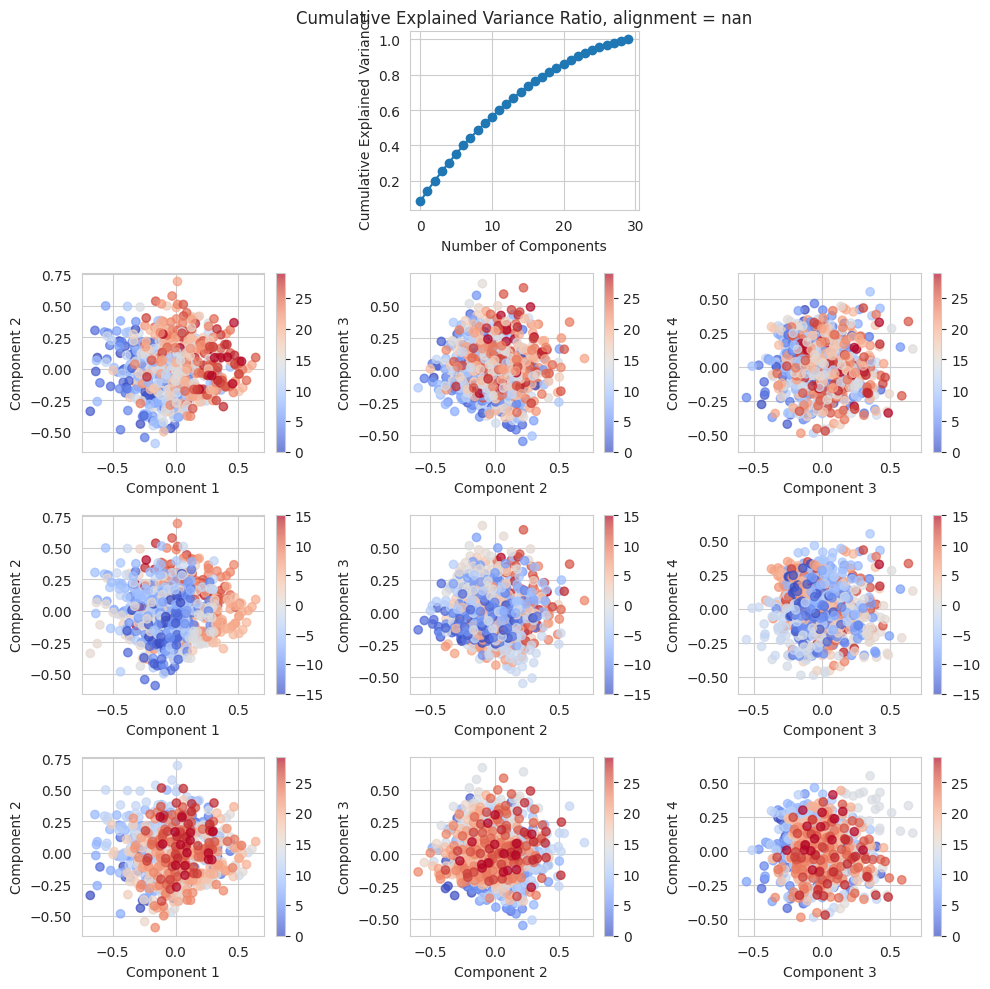

In [ ]:

A, B = factorize_matrix(W_dict['W_model'], N=C.hidden_size)
h_syntetic = X_np @ B.T

pca = PCA().fit(h_syntetic)
pca_corridors = [PCA() for i in range(n_corridors)]
[p.fit(h_syntetic[corridor==i]) for i, p in enumerate(pca_corridors)]
alignment = np.mean([[cosine_similarity(pca_corridors[i].components_[0], pca_corridors[j].components_[0]) for j in range(n_corridors) if j!=i] for i in range(n_corridors)])
X_reduced = pca.transform(h_syntetic)
fig = plt.figure(figsize=(10, 10))

# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title(f'Cumulative Explained Variance Ratio, alignment = {alignment:.2f}')

# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y, action_taken, loc_X]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        s = ax.scatter(X_reduced[:, i], X_reduced[:, i+1], c=c, cmap='coolwarm', alpha=0.7)
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}'),
        ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 61)

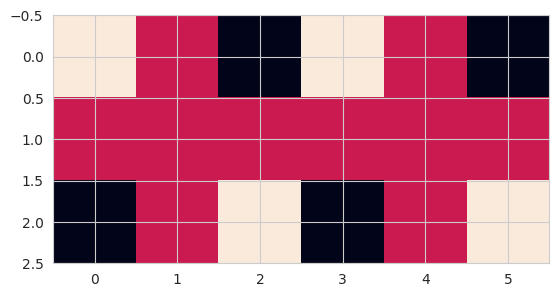

In [ ]:
Win = np.concatenate([np.arange(1,-2,-1), np.arange(1,-2,-1)])[:, None]
Wout = np.arange(1,-2,-1)[None, :]
plt.imshow((Win@Wout).T)
plt.title(((X_np@Win@Wout).argmax(1)==y_np.argmax(1)).mean())

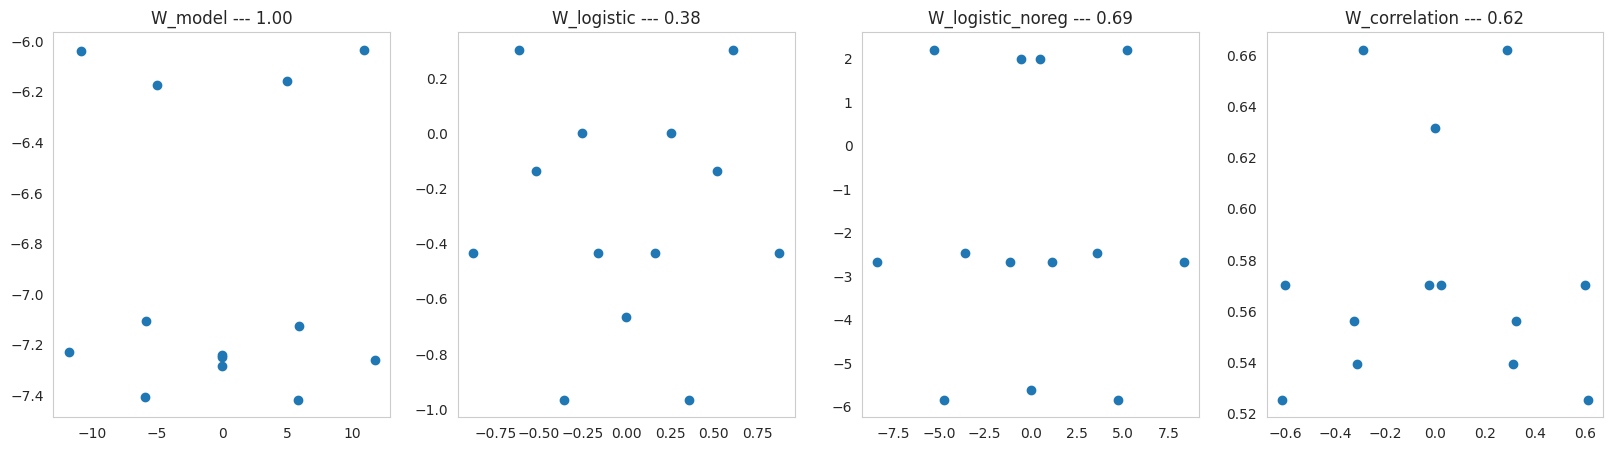

In [ ]:

fig, axs = plt.subplots(1, 4, figsize=(20,5))
for ax, (W_name, W) in zip(axs, W_dict.items()):
    A, B = factorize_matrix(W, N=2)
    ax.scatter((X_np@B.T)[:,0], (X_np@B.T)[:,1])
    ax.set_title(f'{W_name} --- {accuracy_score((X_np@(A@B).T).argmax(1), y_np.argmax(1)):.2f}')
    # ax.set_xticks(np.arange(X_np.shape[1]), [f's = {i}' for i in range(loc_y.max()+1)]+[f'a = {i}' for i in range(-C.max_move, C.max_move+1)], rotation=45)
    ax.grid(False)

(7, 1)
(7, 1)


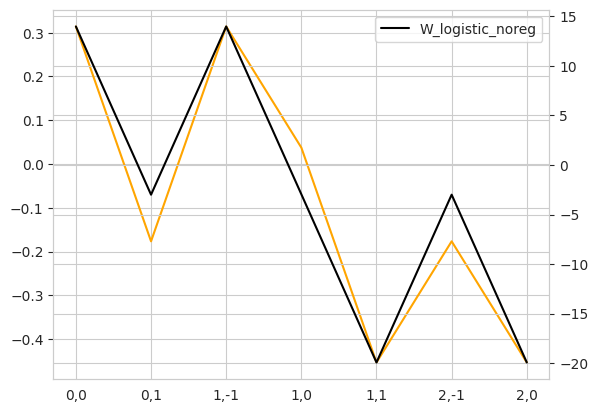

In [ ]:
for i, (k,v)  in enumerate(W_dict.items()):
    if 'logistic' in k:
        distances = np.array(X_np@ v[[0],:].T)
        print(distances.shape)
        if i > 1:
            plt.gca().twinx()
        plt.plot(distances, label=k, c=['b','orange','k','r'][i])
plt.xticks(np.arange(len(X_np)), [f'{x},{a}' for x,a in zip(loc_X,action_taken)])
plt.legend()

In [ ]:
X_np[0]@v.T

array([ 0.8       ,  0.39999998, -0.20000005], dtype=float32)

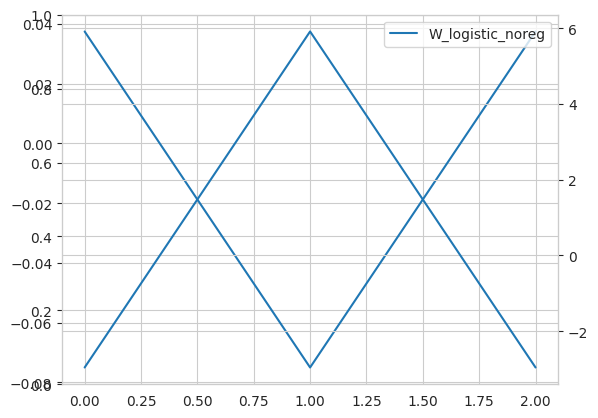

In [ ]:
for k,v  in W_dict.items():
    if 'logistic' in k:
        plt.gca().twinx()
        plt.plot(X_np[3]@v.T, label=k)
plt.legend()

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Train multiclass SVM using one-vs-rest strategy
clf = SVC(kernel='linear', C=1e-6, decision_function_shape='ovr')
clf.fit(X_np, y_np.argmax(1))
print(clf.score(X_np, y_np.argmax(1)))
# Number of classes
n_classes = len(np.unique(y_np.argmax(1)))

# Extract w_SVM and bias b for each class
w_SVM_all = clf.coef_  # shape (n_classes, n_features)
b_all = clf.intercept_  # shape (n_classes,)


0.42857142857142855


In [ ]:
from tqdm import tqdm
lamb_h_l = []
for h in tqdm(hidden_l[::10]):
    lamb_h_l.append(PCA().fit(h[-1]).explained_variance_)

100%|██████████| 100/100 [00:15<00:00,  6.49it/s]


(0.0, 40.57085069417953)

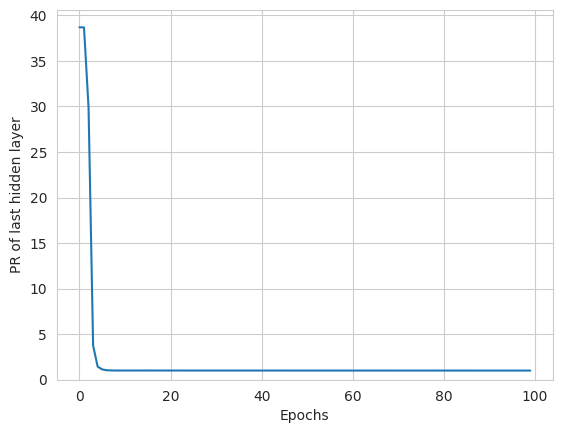

In [ ]:
plt.plot([lamb.sum()**2/(lamb**2).sum() for lamb in lamb_h_l])
plt.ylabel('PR of last hidden layer')
plt.xlabel('Epochs')
plt.ylim(0)

In [ ]:
# # Compute participation ratio for a matrix
# def compute_participation_ratio(matrix):
#     eigenvalues = np.linalg.eigvalsh(matrix @ matrix.T)  # Compute eigenvalues of the covariance matrix
#     eigenvalues = eigenvalues[eigenvalues > 1e-10]  # Filter out near-zero eigenvalues for numerical stability
#     pr = (np.sum(eigenvalues) ** 2) / np.sum(eigenvalues ** 2)
#     return pr
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios = {}
# for name, weight in final_weights.items():
#     weight_np = weight.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios[' '.join(name.split('.')[:-1])] = compute_participation_ratio(weight_np)
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios_h = {}
# for i, h in enumerate([X] + hidden_states + [y]):
#     hid_np = h.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios_h[f'hidden_{i+1}'] = compute_participation_ratio(hid_np)
#
# # Plot the participation ratios
# fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 6))
# ax1.plot(participation_ratios.keys(), participation_ratios.values(), color='skyblue')
# ax1.set_ylim(0)
# ax1.set_xticklabels(participation_ratios.keys(), rotation=45, ha='right')
# ax2.plot(participation_ratios_h.keys(), participation_ratios_h.values(), color='orange')
# # ax2.set_xticks(rotation=45, ha='right')
# ax1.set_ylabel('Participation Ratio')
# ax2.set_ylim(0)
# fig.suptitle('Participation Ratio of Weight Matrices and hiddens')
# plt.tight_layout()
# plt.show()

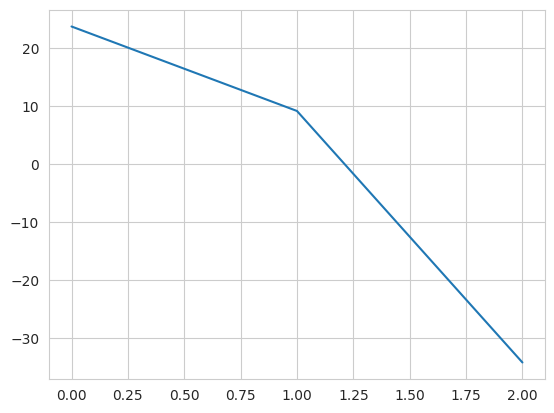

In [ ]:
plt.plot(outputs[0], label='output')
plt.show()

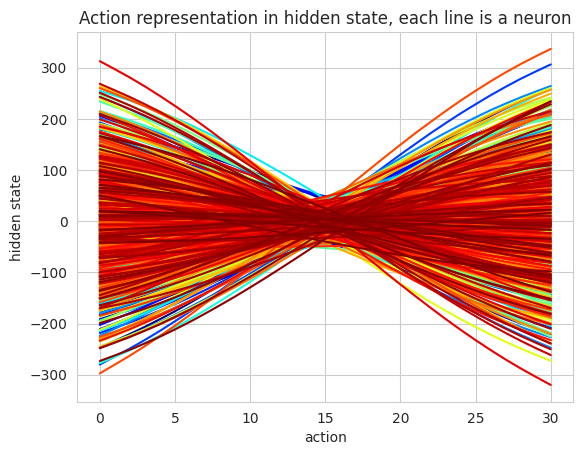

In [ ]:
n_actions = X.shape[1] - sum(C.length_corridors)
a_in_hidden = np.concatenate([np.zeros([n_actions, y.shape[1]]), np.eye(n_actions)],1)
n_states = X.shape[1] - n_actions
s_in_hidden = np.concatenate([np.eye(n_states), np.zeros([n_states, n_actions])],1)
for W in W_l[:-1]:
    a_in_hidden = a_in_hidden @ W.T
    s_in_hidden = s_in_hidden @ W.T

colors = plt.cm.jet(np.linspace(0, 1, a_in_hidden.shape[1]))
for i, color in enumerate(colors):
    plt.plot(np.arange(n_actions), a_in_hidden[:, i], color=color)
plt.xlabel('action')
plt.ylabel('hidden state')
plt.title('Action representation in hidden state, each line is a neuron')
plt.show()


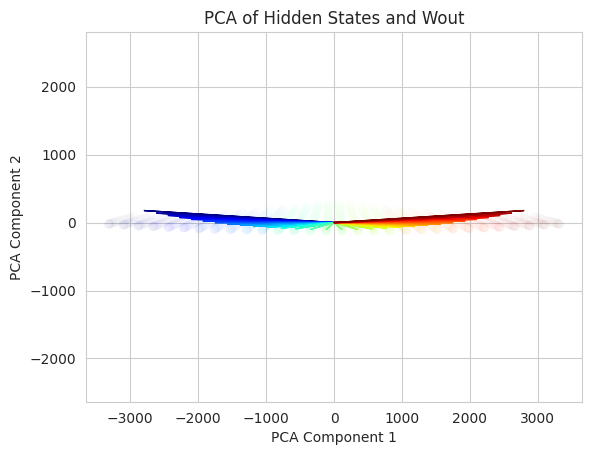

In [ ]:
pca = PCA().fit(hidden)
h_pca = pca.transform(hidden)
Wout_pca = pca.transform(Wout.T)
# scale Wout_pca to be in the same scale as h_pca
Wout_pca = 1*(Wout_pca - Wout_pca.mean(axis=0)) / Wout_pca.std(axis=0) * h_pca.std(axis=0) + h_pca.mean(axis=0)
plt.scatter(h_pca[:, 0], h_pca[:, 1], c=loc_y_corridor, cmap='jet', alpha=0.01)
cmap = plt.cm.jet(np.linspace(0, 1, Wout.shape[1]))
for i in range(Wout.shape[1]):
    plt.arrow(0, 0, Wout_pca[i, 0], Wout_pca[i, 1], color=cmap[i], width=Wout_pca.std()/100)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Hidden States and Wout')
plt.axis('equal')
plt.show()

In [ ]:
a_in_hidden_pca = pca.transform(a_in_hidden)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i in range(2):
    ax = axs[i]
    ax.scatter(h_pca[:, i*2], h_pca[:, i*2+1], c=loc_y_corridor, cmap='jet', alpha=0.02)
    ax.scatter(a_in_hidden_pca[:, i*2], a_in_hidden_pca[:, i*2+1], c=np.arange(n_actions), cmap='seismic', alpha=0.5, label='a_in_hidden PCA', edgecolor='k')
    ax.set_xlabel(f'PCA Component {i*2+1}')
    ax.set_ylabel(f'PCA Component {i*2+2}')
    ax.axis('equal')
fig.suptitle('a_in_hidden in h pca space')
plt.show()

NameError: name 'a_in_hidden' is not defined

In [ ]:
s_in_hidden_pca = pca.transform(s_in_hidden)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i in range(2):
    ax = axs[i]
    ax.scatter(h_pca[:, i*2], h_pca[:, i*2+1], c=loc_y_corridor, cmap='jet', alpha=0.02)
    ax.scatter(s_in_hidden_pca[:, i*2], s_in_hidden_pca[:, i*2+1], c=np.arange(n_states), cmap='seismic', alpha=0.5, label='s_in_hidden PCA')
    ax.set_xlabel(f'PCA Component {i*2+1}')
    ax.set_ylabel(f'PCA Component {i*2+2}')
    ax.axis('equal')
fig.suptitle('s_in_hidden in h pca space')
plt.show()

NameError: name 's_in_hidden' is not defined

100%|██████████| 100/100 [00:01<00:00, 52.51it/s]


Within cluster distance normalized by between cluster distances: 0.74
Within cluster distance normalized by mean hidden norm: 0.09


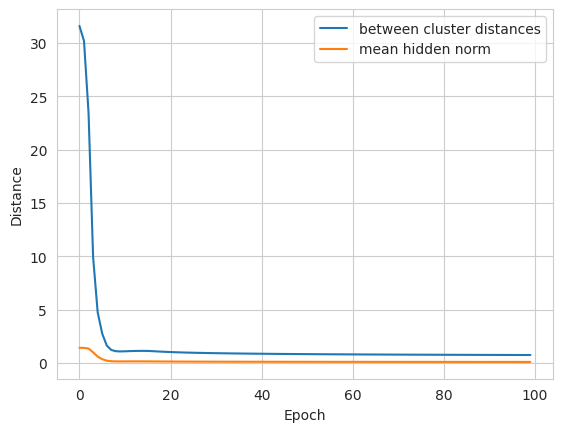

In [ ]:
from utils import get_upper_triangle

d_b = []
d_n = []
for h in tqdm(hidden_l[1::10]):
    h = torch.tensor(h[-1]).to('cuda:2')
    hidden_centers = torch.stack([h[y[:,i]==1].mean(0) for i in range(y.shape[1])])
    hidden_between_cluster_dists = torch.diag(torch.cdist(hidden_centers, hidden_centers),1).mean().item()
    hidden_within_cluster_dists = torch.tensor([get_upper_triangle(torch.cdist(h[y[:,i]==1], h[y[:,i]==1])).mean() for i in range(y.shape[1])]).mean().item()
    hidden_mean_norm = torch.linalg.norm(h, dim=1).mean().item()
    d_n.append(hidden_within_cluster_dists / hidden_mean_norm)
    d_b.append(hidden_within_cluster_dists / hidden_between_cluster_dists)
print(f'Within cluster distance normalized by between cluster distances: {d_b[-1]:.2f}')
print(f'Within cluster distance normalized by mean hidden norm: {d_n[-1]:.2f}')

plt.plot(d_b, label='between cluster distances')
plt.plot(d_n, label='mean hidden norm')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Distance')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

def compute_hessian(W_l, x, target):
    """
    Compute the Hessian of MSE loss w.r.t. the flattened parameters.

    Args:
        W_l (list of torch.Tensor): List of weight matrices (no bias).
        x (torch.Tensor): Input tensor of shape (batch_size, in_features).
        target (torch.Tensor): Target tensor of shape (batch_size, out_features).

    Returns:
        torch.Tensor: 2D Hessian matrix of shape (num_params, num_params).
    """
    # Make sure weights require gradients
    W_l = [w.clone().detach().requires_grad_(True) for w in W_l]

    # Forward pass through layers
    out = x
    for W in W_l:
        out = out @ W.T  # Linear layer without bias

    # Loss (mean squared error)
    loss = F.mse_loss(out, target)

    # Flatten parameters
    params_vector = torch.cat([w.view(-1) for w in W_l])

    # Compute gradients (first-order)
    grads = torch.autograd.grad(loss, W_l, create_graph=True)
    grads_vector = torch.cat([g.view(-1) for g in grads])

    num_params = params_vector.numel()
    hessian = torch.zeros(num_params, num_params)

    for i in range(num_params):
        grad2rd = torch.autograd.grad(grads_vector[i], W_l, retain_graph=True)
        grad2rd_vector = torch.cat([g.contiguous().view(-1) for g in grad2rd])
        hessian[i] = grad2rd_vector

    return hessian


In [ ]:
num_params = sum([len(W.flatten()) for W in W_l])**2
print(num_params)
if num_params < 1e7:
    weights_for_hess = [W for W in final_weights.values()]
    hessian = compute_hessian(weights_for_hess, X, y)
    L, V = torch.linalg.eig(hessian)
    plt.figure(figsize=(12, 6))
    plt.plot(np.abs(L.numpy()))
    plt.yscale('log')


In [ ]:
sing_vals = [np.linalg.svd(W_l[i])[1] for i in range(C.L)]
plt.figure(figsize=(12, 6))
h=[plt.plot(s) for s in sing_vals]

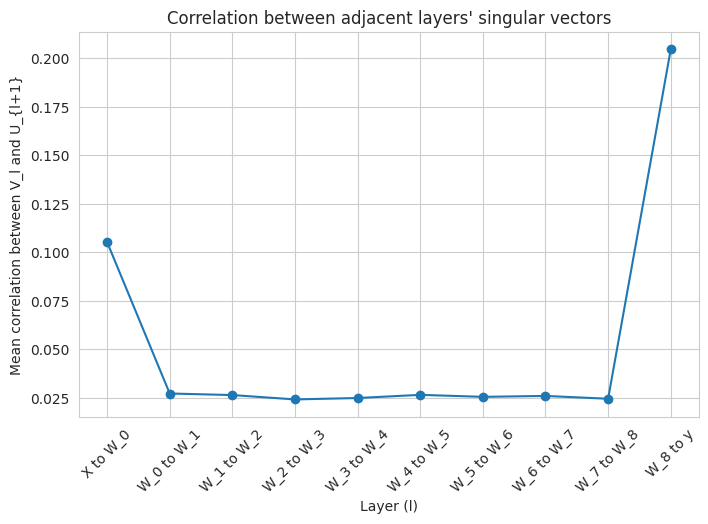

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

matrix_l = [X_np] + [W.T for W in W_l] + [y_np.T]
matrix_names = ['X'] + [f'W_{i}' for i in range(len(W_l))] + ['y']
num_mats = len(matrix_l)
# Step 1: Compute SVDs
svd_results = []
for W in matrix_l:
    U, S, Vt = np.linalg.svd(W)
    svd_results.append({'U': U, 'S': S, 'V': Vt.T})  # Vt.T gives V

# Step 2: Compute correlations between V_l and U_{l+1}
correlations = []
for l in range(num_mats - 1):
    V_l = svd_results[l]['V']  # Output singular vectors of W_l
    U_next = svd_results[l + 1]['U']  # Input singular vectors of W_{l+1}
    S = [svd_results[l]['S'], svd_results[l+1]['S']]
    S = S[np.argmax([min(S[0].shape), min(S[1].shape)])]

    # Compute correlation matrix (dot product between vectors)
    corr_matrix = np.abs(V_l @ U_next)

    # Aggregate correlation (e.g., mean of diagonal as measure)
    corrs = (np.diag(corr_matrix) * S).sum() / S.sum()
    correlations.append(corrs)

# Step 3: Plot
plt.figure(figsize=(8, 5))
plt.plot(range(num_mats-1), correlations, marker='o')
plt.xlabel('Layer (l)')
plt.xticks(range(num_mats-1), [f'{matrix_names[i]} to {matrix_names[i + 1]}' for i in range(num_mats-1)], rotation=45)
plt.ylabel('Mean correlation between V_l and U_{l+1}')
plt.title('Correlation between adjacent layers\' singular vectors')
plt.grid(True)
plt.show()


In [ ]:
h = [plt.plot(svd['S'], label=name) for svd, name in zip(svd_results, matrix_names)]
plt.legend()

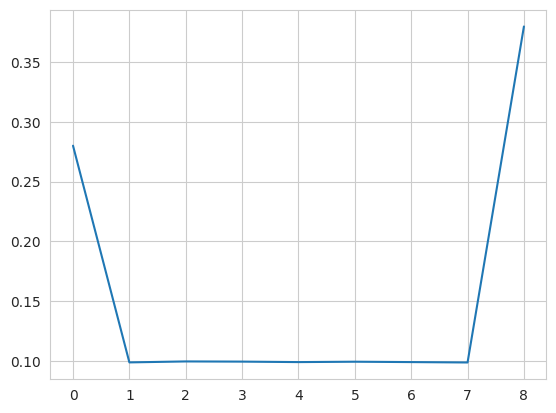

In [ ]:
W_l = [W.cpu().numpy() for W in final_weights.values()]
ratios = []
for W in W_l:
    spectral_norm = np.linalg.norm(W, ord=2)
    frobenius_norm = np.linalg.norm(W, ord='fro')
    ratio = spectral_norm / frobenius_norm if frobenius_norm != 0 else np.nan
    ratios.append(ratio)
plt.plot(ratios)

100%|██████████| 100/100 [01:12<00:00,  1.38it/s]


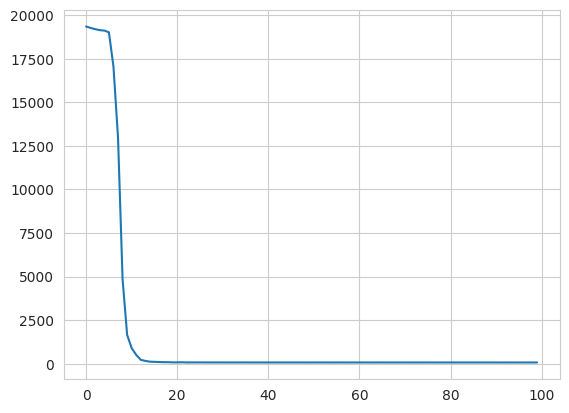

In [ ]:
from scipy.sparse.linalg import svds
classes = np.unique(y_np.argmax(1))
NC1_l = []
for h in tqdm(hidden_l[::10]):
    Sw = 0
    mean_c = []
    for c in classes:
        h_c = torch.tensor(h[-1][y_np.argmax(1)==c])
        z = h_c - h_c.mean(0).unsqueeze(0)
        cov = z.unsqueeze(-1)@z.unsqueeze(1)
        Sw += cov.sum(0)
        mean_c.append(h_c.mean(0))
    Sw /= y_np.shape[0]
    M = torch.stack(mean_c).T
    muG = torch.mean(M, dim=1, keepdim=True) # CHW 1
    M_ = M - muG
    Sb = torch.matmul(M_, M_.T) / len(classes)
    Sw = Sw.cpu().numpy()
    Sb = Sb.cpu().numpy()
    eigvec, eigval, _ = svds(Sb, k=len(classes)-1)
    inv_Sb = eigvec @ np.diag(eigval**(-1)) @ eigvec.T
    NC1_l.append(np.trace(Sw @ inv_Sb))

plt.plot(NC1_l)

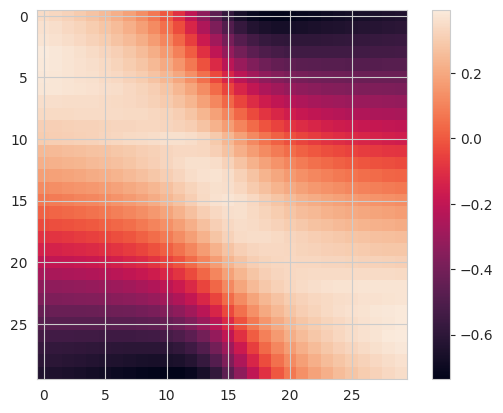

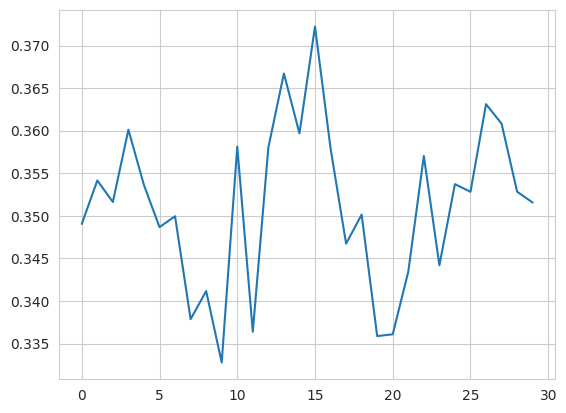

In [ ]:
classes = np.unique(y_np.argmax(1))
y_i = y_np.argmax(1)
hidden_centers = [hidden[y_i==c].mean(0) for c in classes]
hidden_centers = np.stack([h/np.linalg.norm(h) for h in hidden_centers])
Wout = final_weights['output_layer.weight'].cpu().numpy()
Wout /= np.linalg.norm(Wout, axis=1)[:, None]

plt.imshow(Wout@hidden_centers.T)
plt.colorbar()
plt.show()
plt.plot(np.diagonal(Wout@hidden_centers.T))

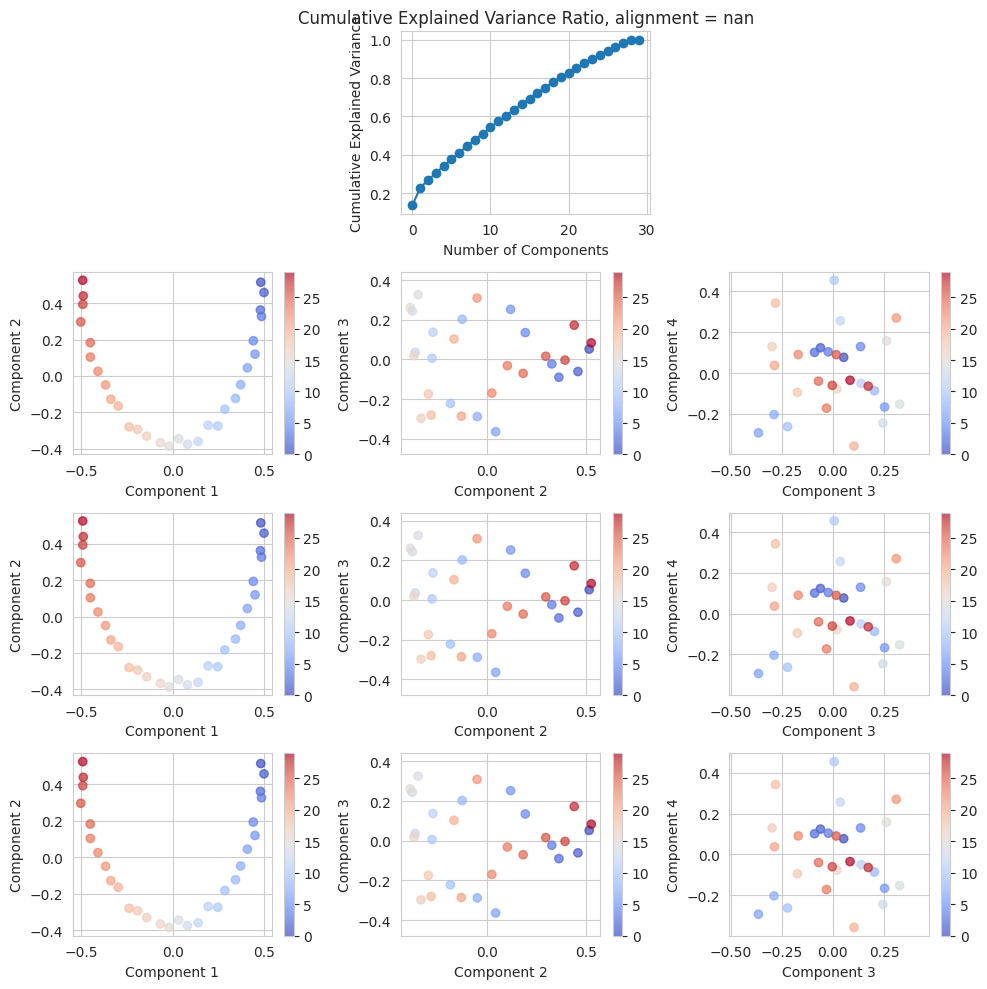

In [ ]:
pca = PCA().fit(Wout)
pca_corridors = [PCA() for i in range(n_corridors)]
X_reduced = pca.transform(Wout)
fig = plt.figure(figsize=(10, 10))

# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title(f'Cumulative Explained Variance Ratio, alignment = {alignment:.2f}')

# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y, action_taken, loc_X]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        s = ax.scatter(X_reduced[:, i], X_reduced[:, i+1], c=np.arange(X_reduced.shape[0]), cmap='coolwarm', alpha=0.7)
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}'),
        ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()